In [1]:
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Statistik
from scipy.stats import skew

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay
)

# Model
from sklearn.ensemble import RandomForestClassifier

# Imbalance Handling
from imblearn.over_sampling import SMOTE

# Ignore warning
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/kaggle/input/datasets/waddahali/fraud-detection/fraud.csv')
print(df.head())
print('\nShape Dataset :', df.shape)

   transaction_amount  hour_of_day  is_weekend  num_items  customer_age  \
0          161.363691          3.0         0.0        2.0     18.000000   
1          116.202851          1.0         1.0        4.0     26.285818   
2            1.000000          2.0         0.0        5.0     18.000000   
3           48.780618          2.0         0.0        3.0     44.471190   
4                 NaN          3.0         0.0        4.0     38.733609   

   prev_transactions  distance_from_home  device_type  network_quality  \
0                2.0           26.539742          1.0        48.403937   
1                2.0           50.714402          NaN        76.144979   
2                NaN            9.467935          0.0        67.600316   
3                NaN           41.077068          0.0        94.825526   
4                8.0                 NaN          2.0       100.000000   

   is_first_transaction  store_type  velocity_score  is_fraud  
0                   0.0         0.0     

In [3]:
df.head()

,transaction_amount,hour_of_day,is_weekend,num_items,customer_age,prev_transactions,distance_from_home,device_type,network_quality,is_first_transaction,store_type,velocity_score,is_fraud
0,161.363691,3.0,0.0,2.0,18.000000,2.0,26.539742,1.0,48.403937,0.0,0.0,3.718296,0
1,116.202851,1.0,1.0,4.0,26.285818,2.0,50.714402,NaN,76.144979,0.0,0.0,4.951272,0
2,1.000000,2.0,0.0,5.0,18.000000,NaN,9.467935,0.0,67.600316,0.0,0.0,4.556043,0
3,48.780618,2.0,0.0,3.0,44.471190,NaN,41.077068,0.0,94.825526,0.0,0.0,6.918437,0
4,NaN,3.0,0.0,4.0,38.733609,8.0,NaN,2.0,100.000000,0.0,1.0,5.535335,1


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   transaction_amount    6440 non-null   float64
 1   hour_of_day           6650 non-null   float64
 2   is_weekend            6860 non-null   float64
 3   num_items             6790 non-null   float64
 4   customer_age          6160 non-null   float64
 5   prev_transactions     6510 non-null   float64
 6   distance_from_home    6300 non-null   float64
 7   device_type           6720 non-null   float64
 8   network_quality       6370 non-null   float64
 9   is_first_transaction  6790 non-null   float64
 10  store_type            6860 non-null   float64
 11  velocity_score        5950 non-null   float64
 12  is_fraud              7000 non-null   int64  
dtypes: float64(12), int64(1)
memory usage: 711.1 KB
None


In [5]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': df.isnull().mean() * 100
})

missing = missing.sort_values(by='Missing Percentage', ascending=False)
print(missing)

                      Missing Count  Missing Percentage
velocity_score                 1050                15.0
customer_age                    840                12.0
distance_from_home              700                10.0
network_quality                 630                 9.0
transaction_amount              560                 8.0
prev_transactions               490                 7.0
hour_of_day                     350                 5.0
device_type                     280                 4.0
num_items                       210                 3.0
is_first_transaction            210                 3.0
is_weekend                      140                 2.0
store_type                      140                 2.0
is_fraud                          0                 0.0


In [6]:
print('Jumlah Duplicate :', df.duplicated().sum())

Jumlah Duplicate : 0


In [7]:
print(df.describe())

       transaction_amount  hour_of_day   is_weekend    num_items  \
count         6440.000000  6650.000000  6860.000000  6790.000000   
mean           100.014648     2.200902     0.108601     2.977320   
std             49.091009     0.677906     0.311160     1.712444   
min              1.000000     1.000000     0.000000     0.000000   
25%             65.711569     2.000000     0.000000     2.000000   
50%             99.482201     2.000000     0.000000     3.000000   
75%            132.897923     3.000000     0.000000     4.000000   
max            296.311885     3.000000     1.000000    13.000000   

       customer_age  prev_transactions  distance_from_home  device_type  \
count   6160.000000        6510.000000         6300.000000  6720.000000   
mean      36.200811           4.457604           24.830735     0.698810   
std       13.283996           4.881635           24.314751     0.776802   
min       18.000000           0.000000            0.004282     0.000000   
25%       25

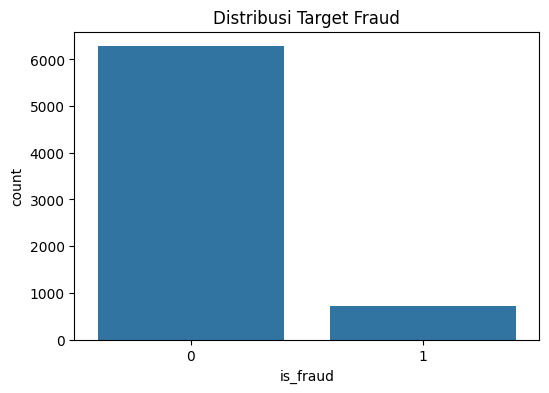

is_fraud
0    89.7
1    10.3
Name: proportion, dtype: float64


In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['is_fraud'])
plt.title('Distribusi Target Fraud')
plt.show()

print(df['is_fraud'].value_counts(normalize=True) * 100)

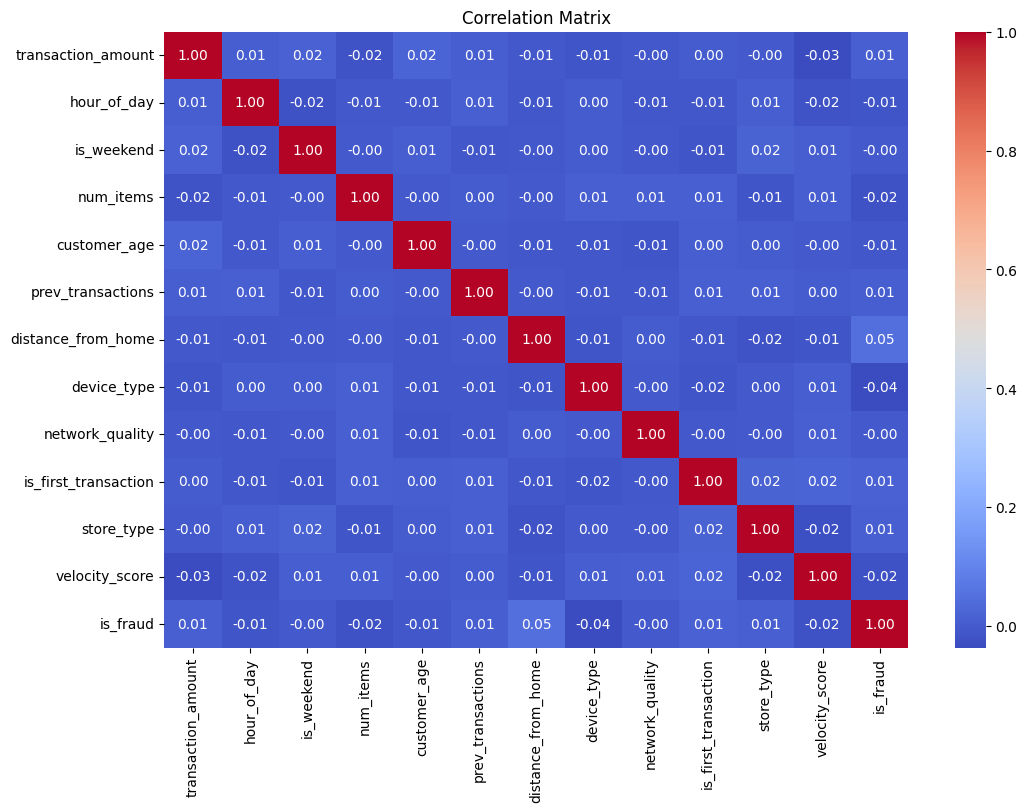

In [9]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

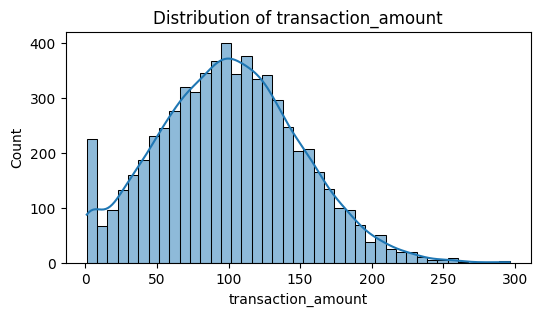

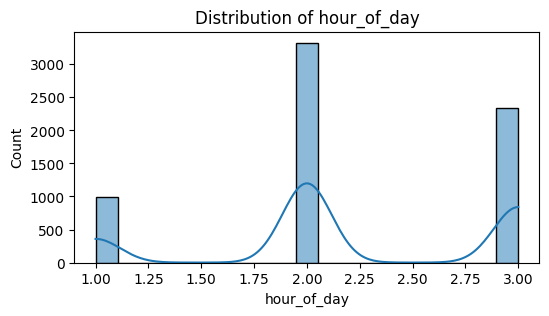

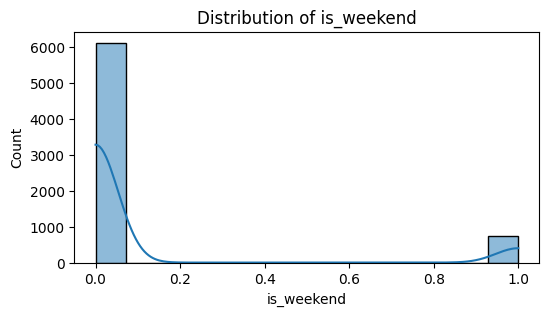

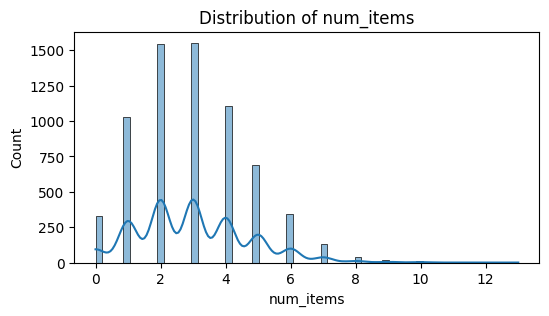

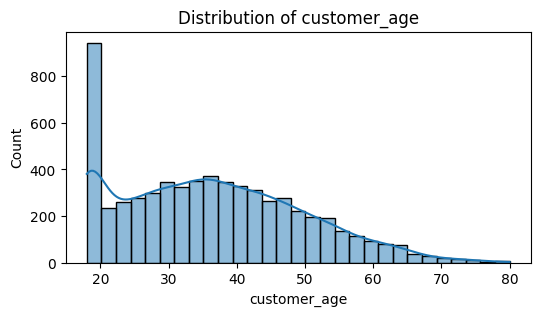

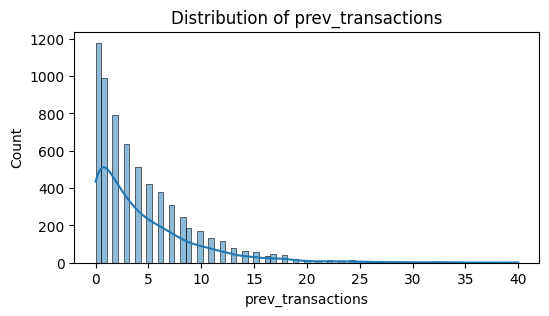

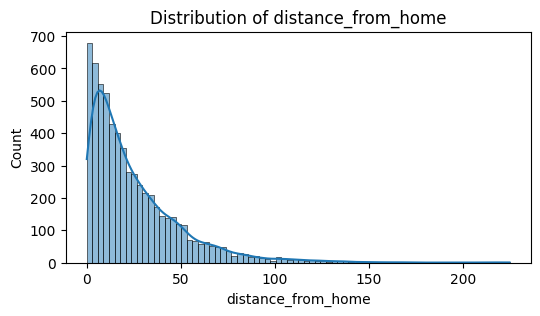

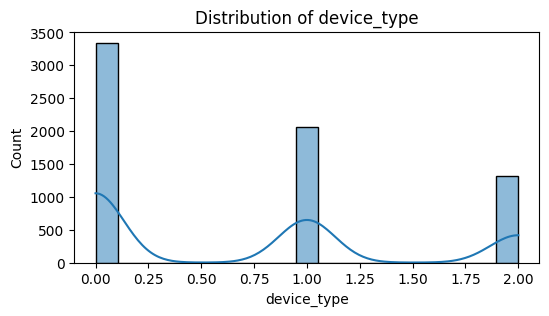

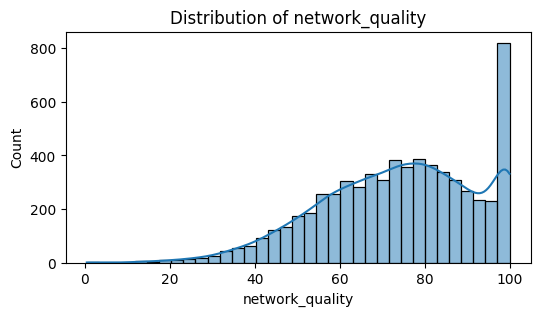

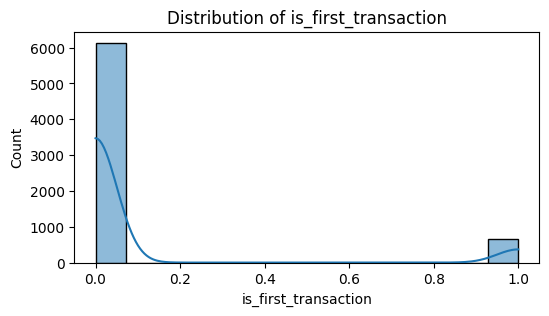

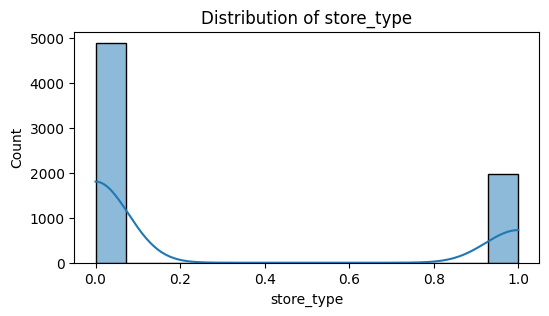

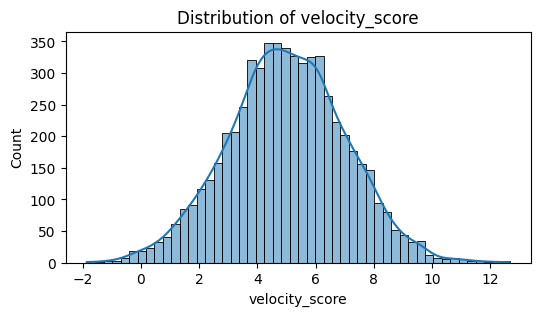

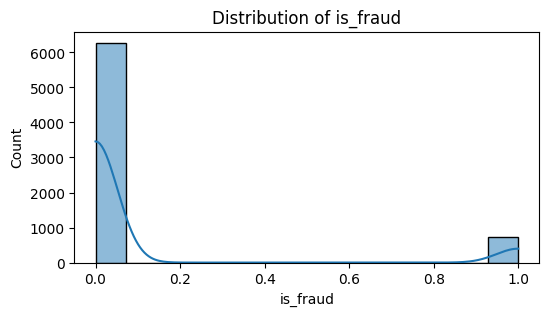

In [10]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

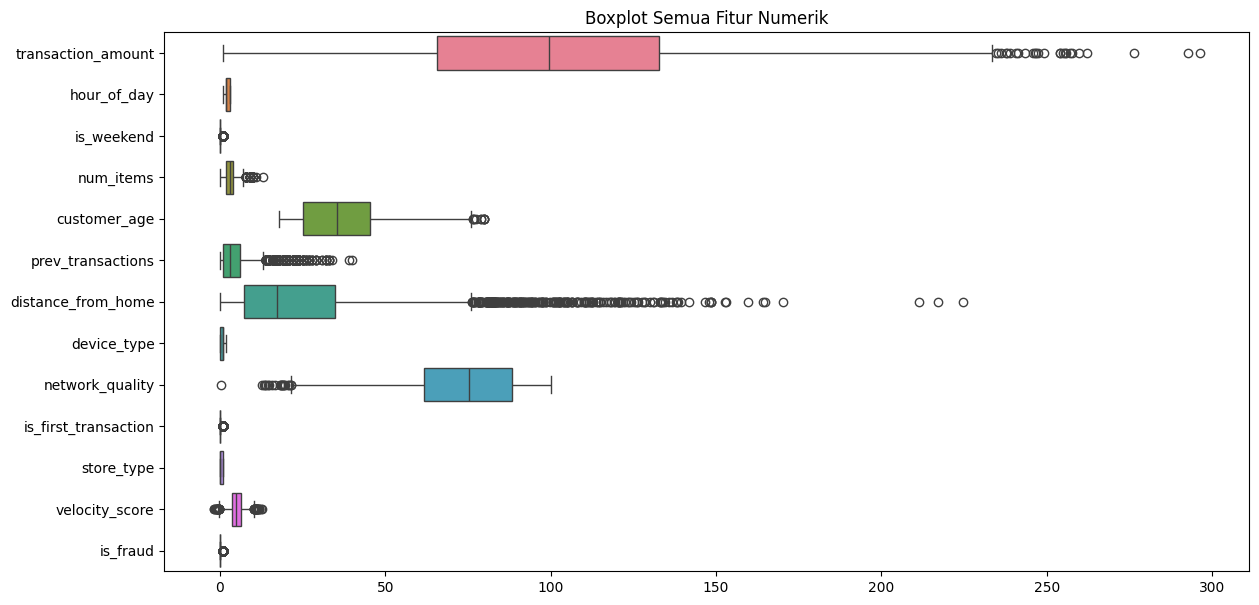

In [11]:
plt.figure(figsize=(14,7))
sns.boxplot(data=df[num_cols], orient='h')
plt.title('Boxplot Semua Fitur Numerik')
plt.show()

In [12]:
# Pisah fitur numerik
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols.remove('is_fraud')
median_imputer = SimpleImputer(strategy='median')

df[numerical_cols] = median_imputer.fit_transform(df[numerical_cols])
print(df.isnull().sum())

transaction_amount      0
hour_of_day             0
is_weekend              0
num_items               0
customer_age            0
prev_transactions       0
distance_from_home      0
device_type             0
network_quality         0
is_first_transaction    0
store_type              0
velocity_score          0
is_fraud                0
dtype: int64


In [13]:
df['amount_per_prev_transaction'] = (
    df['transaction_amount'] / (df['prev_transactions'] + 1)
)


df['velocity_amount_interaction'] = (
    df['velocity_score'] * df['transaction_amount']
)


df['is_night_transaction'] = df['hour_of_day'].apply(
    lambda x: 1 if x >= 22 or x <= 4 else 0
)


df['far_distance_transaction'] = df['distance_from_home'].apply(
    lambda x: 1 if x > df['distance_from_home'].median() else 0
)

print(df.head())

   transaction_amount  hour_of_day  is_weekend  num_items  customer_age  \
0          161.363691          3.0         0.0        2.0     18.000000   
1          116.202851          1.0         1.0        4.0     26.285818   
2            1.000000          2.0         0.0        5.0     18.000000   
3           48.780618          2.0         0.0        3.0     44.471190   
4           99.482201          3.0         0.0        4.0     38.733609   

   prev_transactions  distance_from_home  device_type  network_quality  \
0                2.0           26.539742          1.0        48.403937   
1                2.0           50.714402          1.0        76.144979   
2                3.0            9.467935          0.0        67.600316   
3                3.0           41.077068          0.0        94.825526   
4                8.0           17.321496          2.0       100.000000   

   is_first_transaction  store_type  velocity_score  is_fraud  \
0                   0.0         0.0    

In [14]:
# Cek skewness
skewness = df[numerical_cols].skew().sort_values(ascending=False)
print(skewness)

is_first_transaction    2.803318
is_weekend              2.553012
distance_from_home      2.092364
prev_transactions       2.045283
store_type              0.974652
num_items               0.619588
device_type             0.540753
customer_age            0.485446
transaction_amount      0.172975
velocity_score          0.001631
hour_of_day            -0.231284
network_quality        -0.454985
dtype: float64


In [15]:
skew_cols = [
    'transaction_amount',
    'distance_from_home',
    'velocity_score',
    'prev_transactions'
]

for col in skew_cols:
    df[col] = np.log1p(df[col])

In [16]:
# Function capping outlier

def iqr_capping(data, columns):
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        data[col] = np.where(data[col] > upper, upper, data[col])
        data[col] = np.where(data[col] < lower, lower, data[col])

    return data

outlier_cols = [
    'transaction_amount',
    'distance_from_home',
    'velocity_score',
    'prev_transactions',
    'customer_age',
    'network_quality'
]

df = iqr_capping(df, outlier_cols)

In [17]:
print(df.dtypes)

transaction_amount             float64
hour_of_day                    float64
is_weekend                     float64
num_items                      float64
customer_age                   float64
prev_transactions              float64
distance_from_home             float64
device_type                    float64
network_quality                float64
is_first_transaction           float64
store_type                     float64
velocity_score                 float64
is_fraud                         int64
amount_per_prev_transaction    float64
velocity_amount_interaction    float64
is_night_transaction             int64
far_distance_transaction         int64
dtype: object


In [18]:
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

print('Shape X :', X.shape)
print('Shape y :', y.shape)

Shape X : (7000, 16)
Shape y : (7000,)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('X_train :', X_train.shape)
print('X_test  :', X_test.shape)

X_train : (5600, 16)
X_test  : (1400, 16)


In [20]:
print(X_train.isnull().sum())

print("Total NaN:", X_train.isnull().sum().sum())

X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

imputer_final = SimpleImputer(strategy='median')

X_train = pd.DataFrame(
    imputer_final.fit_transform(X_train),
    columns=X_train.columns
)

X_test = pd.DataFrame(
    imputer_final.transform(X_test),
    columns=X_test.columns
)

print("NaN X_train:", X_train.isnull().sum().sum())
print("NaN X_test :", X_test.isnull().sum().sum())

transaction_amount             0
hour_of_day                    0
is_weekend                     0
num_items                      0
customer_age                   0
prev_transactions              0
distance_from_home             0
device_type                    0
network_quality                0
is_first_transaction           0
store_type                     0
velocity_score                 4
amount_per_prev_transaction    0
velocity_amount_interaction    0
is_night_transaction           0
far_distance_transaction       0
dtype: int64
Total NaN: 4
NaN X_train: 0
NaN X_test : 0


In [21]:
print('Sebelum SMOTE')
print(y_train.value_counts())

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print('\nSesudah SMOTE')
print(y_train_smote.value_counts())

Sebelum SMOTE
is_fraud
0    5023
1     577
Name: count, dtype: int64

Sesudah SMOTE
is_fraud
0    5023
1    5023
Name: count, dtype: int64


In [22]:
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

In [23]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=15,
    min_samples_leaf=8,
    max_features='sqrt',
    bootstrap=True,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train_smote)

RandomForestClassifier(class_weight='balanced', max_depth=8, min_samples_leaf=8,
                       min_samples_split=15, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [24]:
y_pred = rf_model.predict(X_test_scaled)
y_proba = rf_model.predict_proba(X_test_scaled)[:,1]

In [25]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print('Accuracy  :', accuracy)
print('Precision :', precision)
print('Recall    :', recall)
print('F1 Score  :', f1)
print('ROC AUC   :', roc_auc)

Accuracy  : 0.8971428571428571
Precision : 0.0
Recall    : 0.0
F1 Score  : 0.0
ROC AUC   : 0.5501426486199575


In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95      1256
           1       0.00      0.00      0.00       144

    accuracy                           0.90      1400
   macro avg       0.45      0.50      0.47      1400
weighted avg       0.80      0.90      0.85      1400



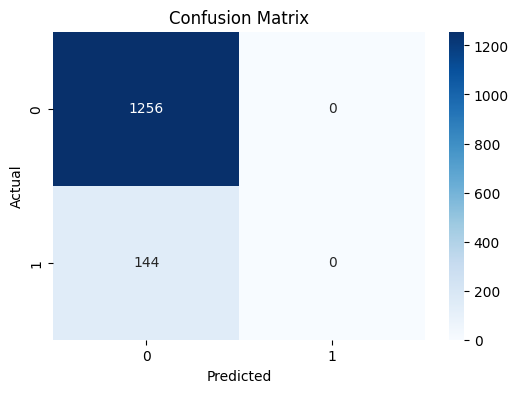

In [27]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

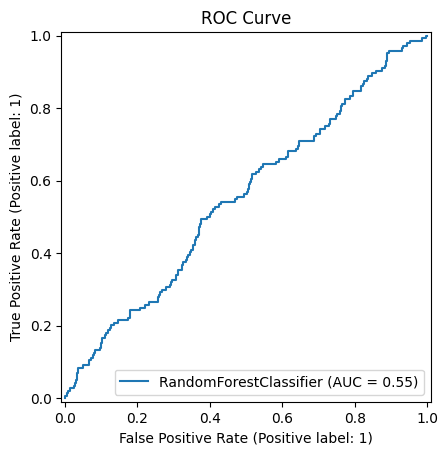

In [28]:
RocCurveDisplay.from_estimator(rf_model, X_test_scaled, y_test)
plt.title('ROC Curve')
plt.show()

In [29]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    rf_model,
    X_train_scaled,
    y_train_smote,
    cv=cv,
    scoring='f1'
)

print('Cross Validation F1 Scores :')
print(cv_scores)

print('\nMean CV Score :', cv_scores.mean())

Cross Validation F1 Scores :
[0.89023718 0.90691345 0.90592713 0.90938687 0.90701468]

Mean CV Score : 0.903895861445293


In [30]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

print(importance)

                        Feature  Importance
15     far_distance_transaction    0.280275
10                   store_type    0.154548
7                   device_type    0.148920
1                   hour_of_day    0.146223
3                     num_items    0.047043
6            distance_from_home    0.046429
2                    is_weekend    0.039315
9          is_first_transaction    0.028597
4                  customer_age    0.019663
13  velocity_amount_interaction    0.019576
8               network_quality    0.015597
11               velocity_score    0.015507
5             prev_transactions    0.013590
12  amount_per_prev_transaction    0.012725
0            transaction_amount    0.011992
14         is_night_transaction    0.000000


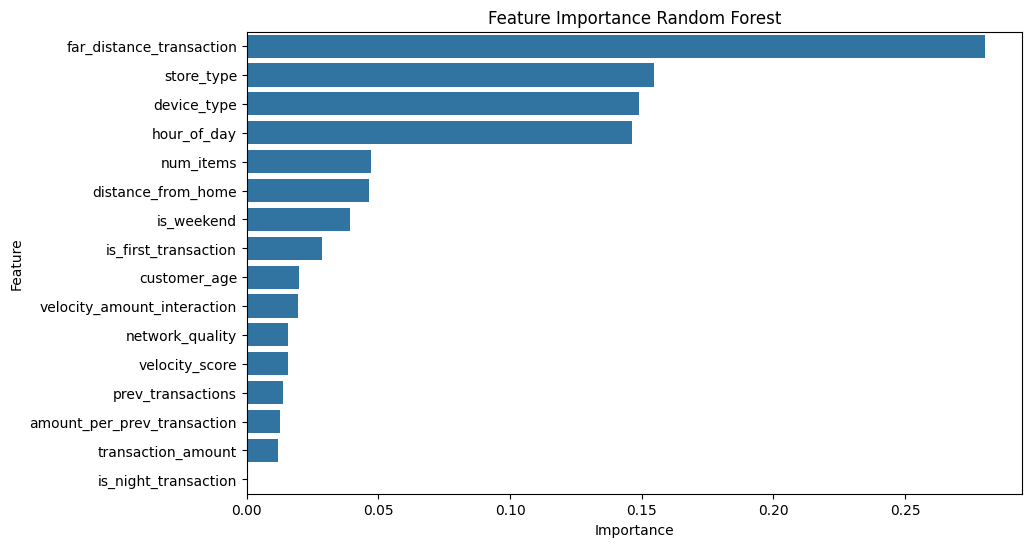

In [31]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance Random Forest')
plt.show()

In [32]:
train_score = rf_model.score(X_train_scaled, y_train_smote)
test_score = rf_model.score(X_test_scaled, y_test)

print('Train Score :', train_score)
print('Test Score  :', test_score)
print('Gap         :', train_score - test_score)

Train Score : 0.9162850885924746
Test Score  : 0.8971428571428571
Gap         : 0.019142231449617464


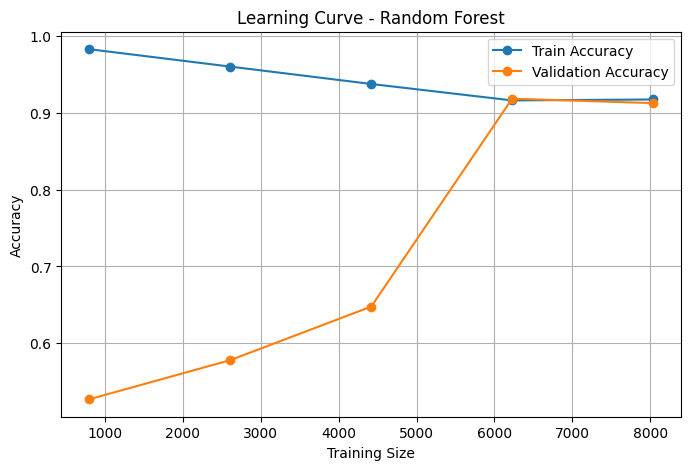

In [33]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

train_sizes, train_scores, val_scores = learning_curve(
    rf_model,
    X_train_scaled,
    y_train_smote,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Mean score
train_scores_mean = np.mean(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)

# Plot
plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    train_scores_mean,
    'o-',
    label='Train Accuracy'
)

plt.plot(
    train_sizes,
    val_scores_mean,
    'o-',
    label='Validation Accuracy'
)

plt.xlabel('Training Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve - Random Forest')
plt.legend()
plt.grid(True)

plt.show()

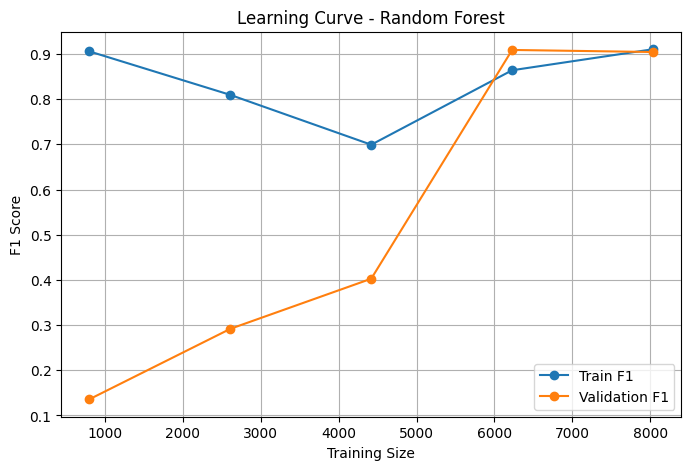

In [34]:
from sklearn.model_selection import learning_curve
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np

# Stratified CV
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_sizes, train_scores, val_scores = learning_curve(
    rf_model,
    X_train_scaled,
    y_train_smote,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1
)

# Mean score
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

# Plot
plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    train_mean,
    'o-',
    label='Train F1'
)

plt.plot(
    train_sizes,
    val_mean,
    'o-',
    label='Validation F1'
)

plt.xlabel('Training Size')
plt.ylabel('F1 Score')
plt.title('Learning Curve - Random Forest')
plt.legend()
plt.grid(True)

plt.show()